In [123]:
import numpy as np
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix


In [124]:
stim_ds = xr.load_dataset("stim_segmented_traces (1).nc")

In [125]:
iti_ds = xr.load_dataset("stim_segmented_greys.nc")

In [126]:
def fix_ds(ds):
    spine_ids = ds["ids"].values
    assert len(spine_ids) == ds.sizes["trial"]

    ds = ds.rename({"ids": "time"})

    ds = ds.assign_coords(spine_id=("trial", spine_ids))

    if "ids" in ds.coords:
        ds = ds.drop_vars("ids")

    return ds

stim_ds = fix_ds(stim_ds)
iti_ds = fix_ds(iti_ds)

print(stim_ds["trace"].dims, stim_ds["trace"].shape)
print(iti_ds["trace"].dims, iti_ds["trace"].shape)
print(stim_ds["spine_id"].dims, stim_ds["spine_id"].shape)
print(iti_ds["spine_id"].dims, iti_ds["spine_id"].shape)

('trial', 'stim_index', 'time') (1917, 96, 120)
('trial', 'stim_index', 'time') (1917, 96, 51)
('trial',) (1917,)
('trial',) (1917,)


In [127]:
spine_id_coord = "spine_id"

def add_row_key(ds, spine_id_coord="spine_id"):
    if "trial" in ds.coords:
        trial_vals = ds["trial"].values
    else:
        trial_vals = np.arange(ds.sizes["trial"])

    spine_vals = ds[spine_id_coord].values

    keys = np.array([
        f"{int(s)}|{t}" if not np.isnan(s) else f"nan|{t}"
        for s, t in zip(spine_vals, trial_vals)
    ], dtype=object)

    return ds.assign_coords(row_key=("trial", keys))

stim_k = add_row_key(stim_ds, spine_id_coord=spine_id_coord)
iti_k = add_row_key(iti_ds, spine_id_coord=spine_id_coord)

common = np.intersect1d(stim_k["row_key"].values, iti_k["row_key"].values)
print("Common rows:", len(common), "of stim:", stim_k.sizes["trial"], "iti:", iti_k.sizes["trial"])

stim_aligned = stim_k.sel(trial=stim_k["row_key"].isin(common)).sortby("row_key")
iti_aligned = iti_k.sel(trial=iti_k["row_key"].isin(common)).sortby("row_key")

assert np.array_equal(stim_aligned["row_key"].values, iti_aligned["row_key"].values)
print("Aligned OK. New n_rows:", stim_aligned.sizes["trial"])

Common rows: 1917 of stim: 1917 iti: 1917
Aligned OK. New n_rows: 1917


In [128]:
def load_data_from_aligned(
    stim_ds,
    iti_ds,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
):
    # remove rows with missing spine ids
    valid_stim = ~np.isnan(stim_ds[spine_id_coord].values)
    valid_iti = ~np.isnan(iti_ds[spine_id_coord].values)

    stim_ds = stim_ds.isel(trial=valid_stim)
    iti_ds = iti_ds.isel(trial=valid_iti)

    # keep only common spine IDs
    stim_spines = np.unique(stim_ds[spine_id_coord].values)
    iti_spines = np.unique(iti_ds[spine_id_coord].values)
    common_spines = np.intersect1d(stim_spines, iti_spines)

    stim_ds = stim_ds.sel(trial=stim_ds[spine_id_coord].isin(common_spines))
    iti_ds = iti_ds.sel(trial=iti_ds[spine_id_coord].isin(common_spines))

    # average repeated rows within each spine
    stim_by_spine = (
        stim_ds[trace_var]
        .groupby(stim_ds[spine_id_coord])
        .mean("trial", skipna=True)
    )

    iti_by_spine = (
        iti_ds[trace_var]
        .groupby(iti_ds[spine_id_coord])
        .mean("trial", skipna=True)
    )

    print("stim_by_spine dims:", stim_by_spine.dims, stim_by_spine.shape)
    print("iti_by_spine dims:", iti_by_spine.dims, iti_by_spine.shape)

    # force explicit order: (spine_id, stim_index, time)
    stim_by_spine = stim_by_spine.transpose(spine_id_coord, "stim_index", "time")
    iti_by_spine = iti_by_spine.transpose(spine_id_coord, "stim_index", "time")

    # convert to decoder format: (stimulus, time, spine)
    stim_data = np.transpose(stim_by_spine.values, (1, 2, 0))
    baseline_data = np.transpose(iti_by_spine.values, (1, 2, 0))

    stim_angles = stim_ds[stim_angle_coord].values

    print("stim_data shape:", stim_data.shape)
    print("baseline_data shape:", baseline_data.shape)
    print("stim_angles shape:", stim_angles.shape)
    print("n common spines:", len(common_spines))

    return stim_data, baseline_data, stim_angles, common_spines

In [129]:
stim_data, iti_data, stim_angles, spine_ids = load_data_from_aligned(
    stim_aligned,
    iti_aligned,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
)

stim_by_spine dims: ('spine_id', 'stim_index', 'time') (544, 96, 120)
iti_by_spine dims: ('spine_id', 'stim_index', 'time') (544, 96, 51)
stim_data shape: (96, 120, 544)
baseline_data shape: (96, 51, 544)
stim_angles shape: (96,)
n common spines: 544


## Decoder

In [130]:
def fit_logreg_on_split(
    X,
    y,
    unique_angles=None,
    train_idx=None,
    test_idx=None,
    test_size=0.2,
    random_state=0,
    max_iter=3000,
    class_weight="balanced",
    shuffle_labels=False,
):
    y = np.asarray(y)

    if unique_angles is None:
        unique_angles = np.sort(np.unique(y))

    if train_idx is None or test_idx is None:
        idx = np.arange(len(y))
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            stratify=y,
            random_state=random_state,
        )

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    if shuffle_labels:
        rng = np.random.default_rng(random_state)
        y_train = rng.permutation(y_train)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = (y_pred == y_test).mean()
    bacc = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=unique_angles)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    per_angle_acc = np.diag(cm_norm)

    return {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "y_test": y_test,
        "y_pred": y_pred,
        "acc": acc,
        "bacc": bacc,
        "cm": cm,
        "cm_norm": cm_norm,
        "per_angle_acc": per_angle_acc,
        "unique_angles": unique_angles,
        "shuffle_labels": shuffle_labels,
    }

In [131]:
def make_repeated_splits(y, n_splits=25, test_size=0.2, seed_start=0):
    y = np.asarray(y)
    idx = np.arange(len(y))
    splits = []

    for split_idx in range(n_splits):
        random_state = seed_start + split_idx
        train_idx, test_idx = train_test_split(
            idx,
            test_size=test_size,
            stratify=y,
            random_state=random_state,
        )
        splits.append((train_idx, test_idx))

    return splits

In [132]:
def build_feature_matrix(
    stim_data,
    baseline_data,
    stim_start=0,
    stim_end=None,
    base_start=0,
    base_end=None,
    feature_types=("mean", "peak", "slope", "integral"),
):
    
    if stim_end is None:
        stim_end = stim_data.shape[1]
    if base_end is None:
        base_end = baseline_data.shape[1]

    stim_win = stim_data[:, stim_start:stim_end, :]       # (trial, time, spine)
    base_win = baseline_data[:, base_start:base_end, :]   # (trial, time, spine)

    # baseline summaries
    base_mean = np.nanmean(base_win, axis=1)              # (trial, spine)

    feature_blocks = []
    feature_names = []

    n_spines = stim_data.shape[2]

    if "mean" in feature_types:
        stim_mean = np.nanmean(stim_win, axis=1)
        feat = stim_mean - base_mean
        feature_blocks.append(feat)
        feature_names.extend([f"mean_spine_{s}" for s in range(n_spines)])

    if "peak" in feature_types:
        stim_peak = np.nanmax(stim_win, axis=1)
        feat = stim_peak - base_mean
        feature_blocks.append(feat)
        feature_names.extend([f"peak_spine_{s}" for s in range(n_spines)])

    if "slope" in feature_types:
        # simple slope: late mean - early mean
        n_t = stim_win.shape[1]
        split = max(1, n_t // 2)
        early = np.nanmean(stim_win[:, :split, :], axis=1)
        late = np.nanmean(stim_win[:, split:, :], axis=1)
        feat = late - early
        feature_blocks.append(feat)
        feature_names.extend([f"slope_spine_{s}" for s in range(n_spines)])

    if "integral" in feature_types:
        # area under baseline-corrected response
        bc = stim_win - base_mean[:, None, :]
        feat = np.nansum(bc, axis=1)
        feature_blocks.append(feat)
        feature_names.extend([f"integral_spine_{s}" for s in range(n_spines)])

    X = np.concatenate(feature_blocks, axis=1)
    return X, feature_names

In [192]:
def decode_angles(
    stim_data,
    baseline_data,
    stim_angles,
    stim_start=0,
    stim_end=120,
    base_start=0,
    base_end=None,
    n_splits=25,
    feature_types=("mean", "peak", "slope", "integral"),
    seed_start=0,
    test_size=0.2,
    plot=True,
    run_shuffle_control=True,
):
    X, feature_names = build_feature_matrix(
        stim_data=stim_data,
        baseline_data=baseline_data,
        stim_start=stim_start,
        stim_end=stim_end,
        base_start=base_start,
        base_end=base_end,
        feature_types=feature_types,
    )    

    y = np.asarray(stim_angles)
    unique_angles = np.sort(np.unique(y))

    splits = make_repeated_splits(
        y=y,
        n_splits=n_splits,
        test_size=test_size,
        seed_start=seed_start,
    )

    results_per_split = []
    shuffle_results_per_split = []

    for split_idx, (train_idx, test_idx) in enumerate(splits):
        res = fit_logreg_on_split(
            X=X,
            y=y,
            unique_angles=unique_angles,
            train_idx=train_idx,
            test_idx=test_idx,
            random_state=seed_start + split_idx,
            shuffle_labels=False,
        )
        results_per_split.append(res)

        if run_shuffle_control:
            shuf_res = fit_logreg_on_split(
                X=X,
                y=y,
                unique_angles=unique_angles,
                train_idx=train_idx,
                test_idx=test_idx,
                random_state=seed_start + split_idx,
                shuffle_labels=True,
            )
            shuffle_results_per_split.append(shuf_res)

    # real decoder summaries
    accs = np.array([r["acc"] for r in results_per_split])
    baccs = np.array([r["bacc"] for r in results_per_split])
    cms = np.array([r["cm_norm"] for r in results_per_split])
    per_angle = np.array([r["per_angle_acc"] for r in results_per_split])

    mean_acc = accs.mean()
    sem_acc = accs.std(ddof=1) / np.sqrt(n_splits)

    mean_bacc = baccs.mean()
    sem_bacc = baccs.std(ddof=1) / np.sqrt(n_splits)

    mean_cm = cms.mean(axis=0)
    mean_per_angle = per_angle.mean(axis=0)
    sem_per_angle = per_angle.std(axis=0, ddof=1) / np.sqrt(n_splits)

    # shuffled summaries
    if run_shuffle_control:
        shuf_accs = np.array([r["acc"] for r in shuffle_results_per_split])
        shuf_baccs = np.array([r["bacc"] for r in shuffle_results_per_split])

        mean_shuf_acc = shuf_accs.mean()
        sem_shuf_acc = shuf_accs.std(ddof=1) / np.sqrt(n_splits)

        mean_shuf_bacc = shuf_baccs.mean()
        sem_shuf_bacc = shuf_baccs.std(ddof=1) / np.sqrt(n_splits)
    else:
        shuf_accs = None
        shuf_baccs = None
        mean_shuf_acc = None
        sem_shuf_acc = None
        mean_shuf_bacc = None
        sem_shuf_bacc = None

    if plot:
        # mean confusion matrix
        plt.figure(figsize=(7, 7))
        plt.imshow(mean_cm, cmap="viridis", aspect="auto")
        plt.colorbar(label="Mean prediction probability")
        plt.xticks(np.arange(len(unique_angles)), unique_angles, rotation=90)
        plt.yticks(np.arange(len(unique_angles)), unique_angles)
        plt.xlabel("Predicted angle")
        plt.ylabel("True angle")
        plt.title(
            f"Cross-cell spines decoder\n"
            f"acc={mean_acc:.3f} ± {sem_acc:.3f}, "
            f"bal acc={mean_bacc:.3f} ± {sem_bacc:.3f}"
        )

        for i, val in enumerate(mean_per_angle):
            plt.text(
                i, i, f"{val:.2f}",
                ha="center",
                va="center",
                color="white" if val < 0.5 else "black",
                fontsize=9,
                fontweight="bold",
            )

        plt.tight_layout()
        plt.show()

        # per-angle accuracy
        plt.figure(figsize=(7, 4))
        plt.bar(unique_angles, mean_per_angle, yerr=sem_per_angle, capsize=4, width=20)
        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xticks(unique_angles, rotation=90)
        plt.xlabel("Angle (degrees)")
        plt.ylabel("Accuracy")
        plt.title("Cross-cell spines per-angle decoding accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # real vs shuffled control
        if run_shuffle_control:
            plt.figure(figsize=(5, 4))
            means = [mean_acc, mean_shuf_acc]
            sems = [sem_acc, sem_shuf_acc]

            plt.bar(["Real", "Shuffled"], means, yerr=sems, capsize=4)
            plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
            plt.ylabel("Accuracy")
            plt.title("Cross-cell spines decoder vs shuffled-label control")
            plt.legend()
            plt.tight_layout()
            plt.show()

    return {
        "X": X,
        "y": y,
        "feature_names": feature_names,
        "splits": splits,
        "results_per_split": results_per_split,
        "shuffle_results_per_split": shuffle_results_per_split,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
        "mean_cm": mean_cm,
        "mean_per_angle": mean_per_angle,
        "sem_per_angle": sem_per_angle,
        "unique_angles": unique_angles,
        "shuf_accs": shuf_accs,
        "shuf_baccs": shuf_baccs,
        "mean_shuf_acc": mean_shuf_acc,
        "sem_shuf_acc": sem_shuf_acc,
        "mean_shuf_bacc": mean_shuf_bacc,
        "sem_shuf_bacc": sem_shuf_bacc,
    }

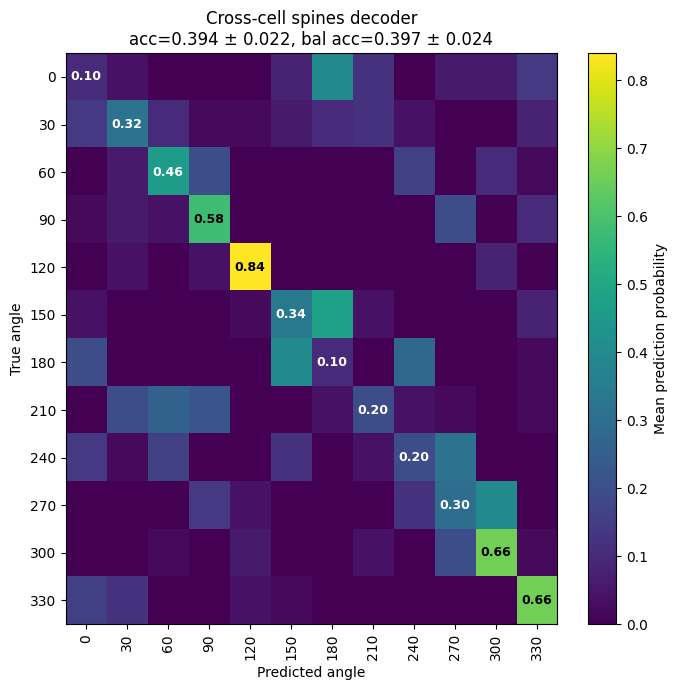

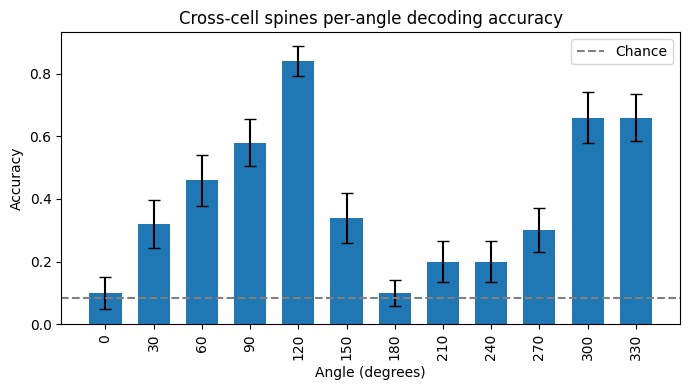

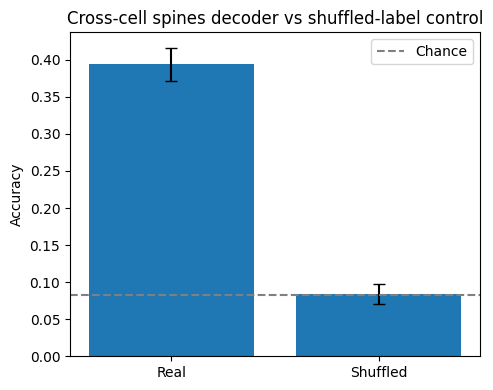

Real accuracy: 0.39399999999999996 ± 0.02223360819420306
Shuffled accuracy: 0.08399999999999999 ± 0.013453624047073712
Chance: 0.08333333333333333


In [193]:
main_results = decode_angles(
    stim_data=stim_data,
    baseline_data=iti_data,
    stim_angles=stim_angles,
    stim_start=0,
    stim_end=120,
    base_start=0,
    base_end=50,
    n_splits=25,
    seed_start=0,
    plot=True,
    run_shuffle_control=True,
)

print("Real accuracy:", main_results["mean_acc"], "±", main_results["sem_acc"])
print("Shuffled accuracy:", main_results["mean_shuf_acc"], "±", main_results["sem_shuf_acc"])
print("Chance:", 1 / len(main_results["unique_angles"]))

In [135]:
def decoding_vs_spine_removal(
    X,
    y,
    osi,
    splits,
    unique_angles=None,
    fractions=None,
    plot=True,
):
    if unique_angles is None:
        unique_angles = np.sort(np.unique(y))

    if fractions is None:
        fractions = np.linspace(0, 0.5, 10)

    order = np.argsort(osi)[::-1]

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(fractions)))
    bacc_matrix = np.zeros((n_splits, len(fractions)))
    n_spines_used = np.zeros(len(fractions), dtype=int)

    for split_idx, (train_idx, test_idx) in enumerate(splits):
        for j, frac in enumerate(fractions):
            n_remove = int(frac * len(order))
            keep = order[n_remove:]
            n_spines_used[j] = len(keep)

            X_sub = X[:, keep]

            res = fit_logreg_on_split(
                X=X_sub,
                y=y,
                unique_angles=unique_angles,
                train_idx=train_idx,
                test_idx=test_idx,
            )

            acc_matrix[split_idx, j] = res["acc"]
            bacc_matrix[split_idx, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(fractions * 100, mean_acc, marker="o", label="Accuracy")
        plt.fill_between(fractions * 100, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(fractions * 100, mean_bacc, marker="o", label="Balanced accuracy")
        plt.fill_between(fractions * 100, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("% highest OSI spines removed")
        plt.ylabel("Decoding performance")
        plt.title("Cross-cell spines decoding vs removing most selective spines")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "fractions": np.array(fractions),
        "n_spines_used": n_spines_used,
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

In [136]:
def compute_OSI(stim_data, iti_data, stim_angles):

    stim_start, stim_end = 0, stim_data.shape[1]
    base_start, base_end = 0, iti_data.shape[1]

    stim_resp = np.nanmean(stim_data[:, stim_start:stim_end, :], axis=1)
    base_resp = np.nanmean(iti_data[:, base_start:base_end, :], axis=1)
    resp = stim_resp - base_resp
    all_angles = np.asarray(stim_angles)

    unique_angles = np.sort(np.unique(all_angles))

    tuning = np.stack(
        [resp[stim_angles == ang].mean(axis=0) for ang in unique_angles],
        axis=0
    )  # (n_angles, n_spines)

    theta = np.deg2rad(unique_angles)

    R = np.maximum(tuning.T, 0)  # shape: (n_spines, n_angles)

    x = (R * np.cos(2 * theta)).sum(axis=1)
    y = (R * np.sin(2 * theta)).sum(axis=1)
    magnitude = np.sqrt(x**2 + y**2)

    osi = magnitude / (R.sum(axis=1) + 1e-9)

    return resp, all_angles, unique_angles, osi

In [137]:
_, _ , _ , osi = compute_OSI(stim_data, iti_data, stim_angles)

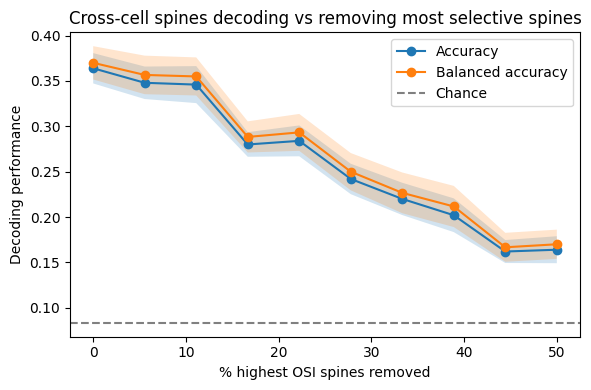

In [138]:
osi_results = decoding_vs_spine_removal(
    X=main_results["X"],
    y=main_results["y"],
    osi=osi,
    splits=main_results["splits"],
    unique_angles=main_results["unique_angles"],
    plot=True,
)

In [139]:
def sliding_window_decode(
    stim_data,
    baseline_data,
    stim_angles,
    splits,
    window_size=10,
    step_size=1,
    base_start=0,
    base_end=None,
    plot=True,
):
    n_trials, n_time, n_spines = stim_data.shape

    if base_end is None:
        base_end = baseline_data.shape[1]

    y = np.asarray(stim_angles)
    unique_angles = np.sort(np.unique(y))

    base_resp = np.nanmean(baseline_data[:, base_start:base_end, :], axis=1)

    starts = np.arange(0, n_time - window_size + 1, step_size)
    centers = starts + window_size / 2

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(starts)))
    bacc_matrix = np.zeros((n_splits, len(starts)))

    for split_idx, (train_idx, test_idx) in enumerate(splits):
        for j, start in enumerate(starts):
            end = start + window_size

            stim_resp = np.nanmean(stim_data[:, start:end, :], axis=1)
            X = stim_resp - base_resp

            res = fit_logreg_on_split(
                X=X,
                y=y,
                unique_angles=unique_angles,
                train_idx=train_idx,
                test_idx=test_idx,
            )

            acc_matrix[split_idx, j] = res["acc"]
            bacc_matrix[split_idx, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(7, 4))
        plt.plot(centers, mean_acc, label="Accuracy")
        plt.fill_between(centers, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(centers, mean_bacc, label="Balanced accuracy")
        plt.fill_between(centers, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("Window center (frames)")
        plt.ylabel("Decoding performance")
        plt.title("Cross-cell spines sliding-window decoding")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "window_centers": centers,
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

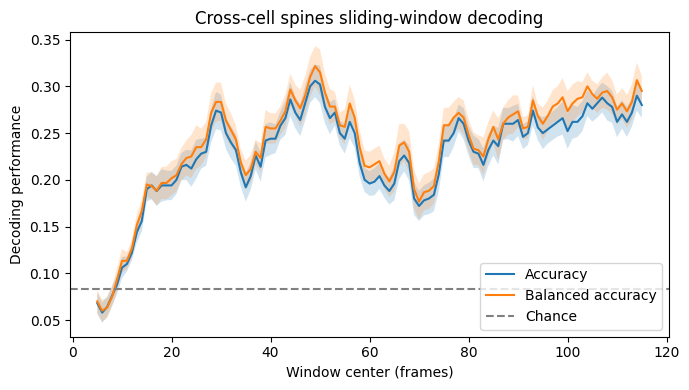

In [140]:
time_results = sliding_window_decode(
    stim_data=stim_data,
    baseline_data=iti_data,
    stim_angles=stim_angles,
    splits=main_results["splits"],
    window_size=10,
    step_size=1,
    base_start=0,
    base_end=50,
    plot=True,
)

In [141]:
def compare_feature_types(
    stim_data,
    baseline_data,
    stim_angles,
    stim_start=0,
    stim_end=None,
    base_start=0,
    base_end=None,
    n_splits=25,
    seed_start=0,
):
    feature_sets = {
        "mean": ("mean",),
        "peak": ("peak",),
        "slope": ("slope",),
        "integral": ("integral",),
        "mean+peak": ("mean", "peak"),
        "all": ("mean", "peak", "slope", "integral"),
    }

    labels = []
    accs = []
    baccs = []

    for label, feat_types in feature_sets.items():
        res = decode_angles(
            stim_data=stim_data,
            baseline_data=baseline_data,
            stim_angles=stim_angles,
            stim_start=stim_start,
            stim_end=stim_end,
            base_start=base_start,
            base_end=base_end,
            feature_types=feat_types,
            n_splits=n_splits,
            seed_start=seed_start,
            plot=False,
        )
        labels.append(label)
        accs.append(res["mean_acc"])
        baccs.append(res["mean_bacc"])

    return labels, np.array(accs), np.array(baccs)

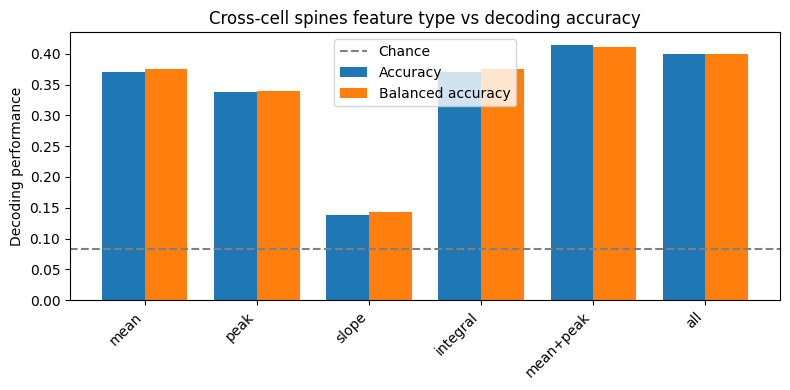

In [142]:
labels, accs, baccs = compare_feature_types(
    stim_data=stim_data,
    baseline_data=iti_data,
    stim_angles=stim_angles,
    stim_start=0,
    stim_end=120,
    base_start=0,
    base_end=51,
    n_splits=25,
    seed_start=0,
)

chance = 1 / len(np.unique(stim_angles))

x = np.arange(len(labels))
width = 0.38

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, accs, width=width, label="Accuracy")
plt.bar(x + width/2, baccs, width=width, label="Balanced accuracy")
plt.axhline(chance, linestyle="--", color="gray", label="Chance")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Decoding performance")
plt.title("Cross-cell spines feature type vs decoding accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Pseudopopulation Decoder

In [164]:
def make_feature_matrix_from_aligned(
    stim_aligned,
    iti_aligned,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
    feature_types=("mean", "peak", "slope", "integral"),
):

    stim_da = stim_aligned[trace_var].isel(time=stim_win)   # (row, stim, time)
    iti_da = iti_aligned[trace_var].isel(time=iti_win)      # (row, stim, time)

    # baseline mean used for several features
    base_mean = iti_da.mean("time", skipna=True)            # (row, stim)

    feature_blocks = []

    if "mean" in feature_types:
        stim_mean = stim_da.mean("time", skipna=True)
        feat = (stim_mean - base_mean).values               # (row, stim)
        feature_blocks.append(feat)

    if "peak" in feature_types:
        stim_peak = stim_da.max("time", skipna=True)
        feat = (stim_peak - base_mean).values               # (row, stim)
        feature_blocks.append(feat)

    if "slope" in feature_types:
        n_t = stim_da.sizes["time"]
        split = max(1, n_t // 2)
        early = stim_da.isel(time=slice(0, split)).mean("time", skipna=True)
        late = stim_da.isel(time=slice(split, n_t)).mean("time", skipna=True)
        feat = (late - early).values                        # (row, stim)
        feature_blocks.append(feat)

    if "integral" in feature_types:
        # baseline-corrected area under the response
        bc = stim_da - base_mean
        feat = bc.sum("time", skipna=True).values          # (row, stim)
        feature_blocks.append(feat)

    # stack -> (row, stim, feature)
    feature_values = np.stack(feature_blocks, axis=-1)

    angles_by_si = stim_aligned[stim_angle_coord].values
    unique_angles = np.sort(np.unique(angles_by_si))

    spine_ids = stim_aligned[spine_id_coord].values
    valid_rows = np.where(~np.isnan(spine_ids))[0]

    sp_to_rows = {}
    for r in valid_rows:
        sid = spine_ids[r]
        sp_to_rows.setdefault(sid, []).append(r)

    keep_spines = np.array(sorted(sp_to_rows.keys()))

    return feature_values, angles_by_si, keep_spines, sp_to_rows, unique_angles, tuple(feature_types)

In [165]:
def make_pseudopop_draw(feature_values, spines, sp_to_rows, rng):
    
    chosen_rows = np.array([rng.choice(sp_to_rows[sid]) for sid in spines])

    # (n_spines, n_stim, n_features)
    R = feature_values[chosen_rows, :, :]

    # reorder to (n_stim, n_spines, n_features), then flatten feature axis
    X_draw = np.transpose(R, (1, 0, 2)).reshape(R.shape[1], -1)

    return X_draw

In [166]:
def build_pseudopop_tensor(feature_values, spines, sp_to_rows, n_draws=100, rng_seed=0):
    rng = np.random.default_rng(rng_seed)

    n_stim = feature_values.shape[1]
    n_features = feature_values.shape[2]

    X_draws = np.zeros((n_draws, n_stim, len(spines) * n_features), dtype=np.float64)

    for d in range(n_draws):
        X_draws[d] = make_pseudopop_draw(feature_values, spines, sp_to_rows, rng)

    return X_draws

In [167]:
def make_repeated_draw_splits(n_draws, n_splits=25, test_size=0.2, seed_start=0):
    
    draw_ids = np.arange(n_draws)
    splits = []

    for i in range(n_splits):
        train_draws, test_draws = train_test_split(
            draw_ids,
            test_size=test_size,
            random_state=seed_start + i,
        )
        splits.append((train_draws, test_draws))

    return splits

In [168]:
def fit_logreg_on_draw_split(
    X_draws,
    angles_by_si,
    train_draws,
    test_draws,
    unique_angles=None,
    shuffle_labels=False,
    random_state=0,
    max_iter=5000,
    class_weight="balanced",
):
    
    if unique_angles is None:
        unique_angles = np.sort(np.unique(angles_by_si))

    # Collapse draw dimension into samples
    X_train = X_draws[train_draws].reshape(-1, X_draws.shape[-1])
    X_test = X_draws[test_draws].reshape(-1, X_draws.shape[-1])

    # Repeat angle labels once per draw
    y_train = np.tile(angles_by_si, len(train_draws))
    y_test = np.tile(angles_by_si, len(test_draws))

    # Optional shuffle control: shuffle training labels only
    if shuffle_labels:
        rng = np.random.default_rng(random_state)
        y_train = rng.permutation(y_train)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(
        max_iter=max_iter,
        class_weight=class_weight,
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = (y_pred == y_test).mean()
    bacc = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=unique_angles)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    per_angle_acc = np.diag(cm_norm)

    return {
        "acc": acc,
        "bacc": bacc,
        "cm": cm,
        "cm_norm": cm_norm,
        "per_angle_acc": per_angle_acc,
        "y_test": y_test,
        "y_pred": y_pred,
        "clf": clf,
    }

In [169]:
def pseudopop_mean_window_decode(
    stim_aligned,
    iti_aligned,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
    feature_types=("mean", "peak", "slope", "integral"),
    min_repeats_per_spine=3,
    n_draws=100,
    n_splits=25,
    seed_start=0,
    plot=True,
    run_shuffle_control=True,
):
    feature_values, angles_by_si, all_spines, sp_to_rows, unique_angles, feature_types = (
        make_feature_matrix_from_aligned(
            stim_aligned=stim_aligned,
            iti_aligned=iti_aligned,
            trace_var=trace_var,
            spine_id_coord=spine_id_coord,
            stim_angle_coord=stim_angle_coord,
            stim_win=stim_win,
            iti_win=iti_win,
            feature_types=feature_types,
        )
    )

    keep_spines = np.array([sid for sid in all_spines if len(sp_to_rows[sid]) >= min_repeats_per_spine])

    X_draws = build_pseudopop_tensor(
        feature_values=feature_values,
        spines=keep_spines,
        sp_to_rows=sp_to_rows,
        n_draws=n_draws,
        rng_seed=seed_start,
    )

    splits = make_repeated_draw_splits(
        n_draws=n_draws,
        n_splits=n_splits,
        seed_start=seed_start,
    )

    results = []
    shuf_results = []

    for i, (train_draws, test_draws) in enumerate(splits):
        res = fit_logreg_on_draw_split(
            X_draws=X_draws,
            angles_by_si=angles_by_si,
            train_draws=train_draws,
            test_draws=test_draws,
            unique_angles=unique_angles,
            shuffle_labels=False,
            random_state=seed_start + i,
        )
        results.append(res)

        if run_shuffle_control:
            sres = fit_logreg_on_draw_split(
                X_draws=X_draws,
                angles_by_si=angles_by_si,
                train_draws=train_draws,
                test_draws=test_draws,
                unique_angles=unique_angles,
                shuffle_labels=True,
                random_state=seed_start + i,
            )
            shuf_results.append(sres)

    accs = np.array([r["acc"] for r in results])
    baccs = np.array([r["bacc"] for r in results])
    cms = np.array([r["cm_norm"] for r in results])
    per_angle = np.array([r["per_angle_acc"] for r in results])

    mean_acc = accs.mean()
    sem_acc = accs.std(ddof=1) / np.sqrt(n_splits)

    mean_bacc = baccs.mean()
    sem_bacc = baccs.std(ddof=1) / np.sqrt(n_splits)

    mean_cm = cms.mean(axis=0)
    mean_per_angle = per_angle.mean(axis=0)
    sem_per_angle = per_angle.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if run_shuffle_control:
        shuf_accs = np.array([r["acc"] for r in shuf_results])
        mean_shuf_acc = shuf_accs.mean()
        sem_shuf_acc = shuf_accs.std(ddof=1) / np.sqrt(n_splits)
    else:
        shuf_accs = None
        mean_shuf_acc = None
        sem_shuf_acc = None

    if plot:
        plt.figure(figsize=(7, 7))
        plt.imshow(mean_cm, cmap="viridis", aspect="auto")
        plt.colorbar(label="Mean prediction probability")
        plt.xticks(np.arange(len(unique_angles)), unique_angles, rotation=90)
        plt.yticks(np.arange(len(unique_angles)), unique_angles)
        plt.xlabel("Predicted angle")
        plt.ylabel("True angle")
        plt.title(
            f"Cross-cell spine pseudopop decoder\n"
            f"acc={mean_acc:.3f} ± {sem_acc:.3f}, "
            f"bal acc={mean_bacc:.3f} ± {sem_bacc:.3f}"
        )

        for i, val in enumerate(mean_per_angle):
            plt.text(
                i, i, f"{val:.2f}",
                ha="center", va="center",
                color="white" if val < 0.5 else "black",
                fontsize=9, fontweight="bold"
            )
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.bar(unique_angles, mean_per_angle, yerr=sem_per_angle, capsize=4, width=20)
        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xticks(unique_angles, rotation=90)
        plt.xlabel("Angle (degrees)")
        plt.ylabel("Accuracy")
        plt.title(f"Cross-cell spine pseudopop per-angle decoding accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

        if run_shuffle_control:
            plt.figure(figsize=(5, 4))
            plt.bar(
                ["Real", "Shuffled"],
                [mean_acc, mean_shuf_acc],
                yerr=[sem_acc, sem_shuf_acc],
                capsize=4,
            )
            plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
            plt.ylabel("Accuracy")
            plt.title(f"Cross-cell spine pseudopop decoder vs shuffled")
            plt.legend()
            plt.tight_layout()
            plt.show()

    return {
        "feature_values": feature_values,
        "angles_by_si": angles_by_si,
        "keep_spines": keep_spines,
        "sp_to_rows": sp_to_rows,
        "unique_angles": unique_angles,
        "feature_types": feature_types,
        "X_draws": X_draws,
        "splits": splits,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
        "mean_cm": mean_cm,
        "mean_per_angle": mean_per_angle,
        "sem_per_angle": sem_per_angle,
        "mean_shuf_acc": mean_shuf_acc,
        "sem_shuf_acc": sem_shuf_acc,
    }

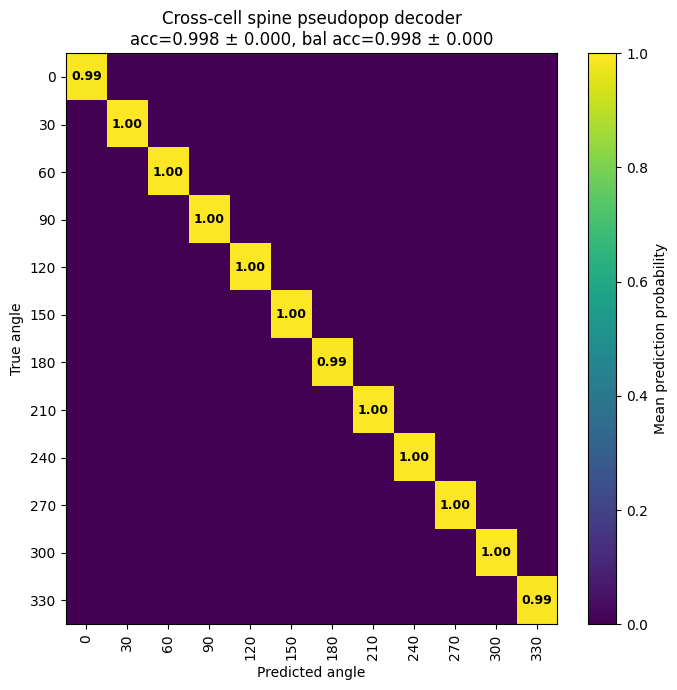

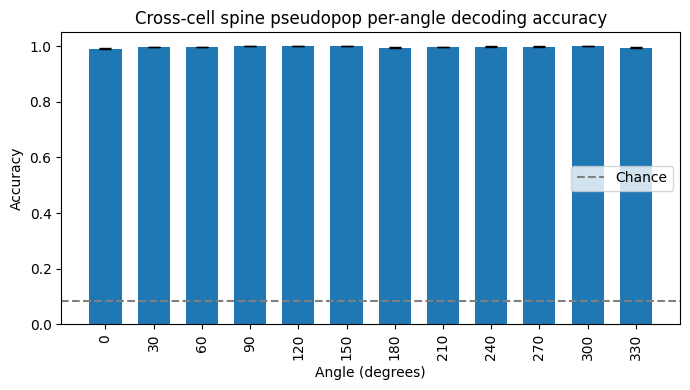

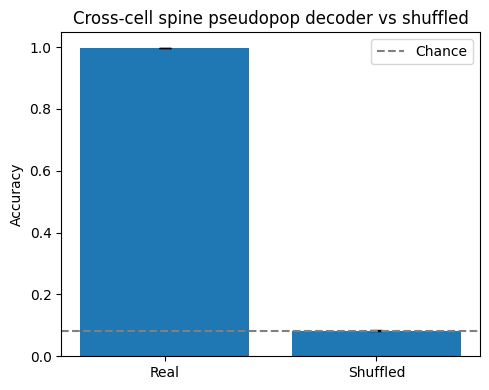

In [170]:
pseudopop_main_results = pseudopop_mean_window_decode(
    stim_aligned=stim_aligned,
    iti_aligned=iti_aligned,
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
    min_repeats_per_spine=3,
    n_draws=100,
    n_splits=25,
    seed_start=0,
    plot=True,
    run_shuffle_control=True,
)

In [191]:
main_results["mean_shuf_acc"]

np.float64(0.08399999999999999)

In [190]:
pseudopop_main_results["mean_shuf_acc"]

np.float64(0.08297916666666667)

In [150]:
def compare_pseudopop_feature_types(
    stim_aligned,
    iti_aligned,
    feature_sets=None,
    **kwargs,
):
    if feature_sets is None:
        feature_sets = {
            "mean": ("mean",),
            "peak": ("peak",),
            "slope": ("slope",),
            "integral": ("integral",),
            "mean+peak": ("mean", "peak"),
            "all": ("mean", "peak", "slope", "integral"),
        }

    labels = []
    accs = []
    baccs = []

    for label, feat_types in feature_sets.items():
        res = pseudopop_mean_window_decode(
            stim_aligned=stim_aligned,
            iti_aligned=iti_aligned,
            feature_types=feat_types,
            plot=False,
            run_shuffle_control=False,
            **kwargs,
        )
        labels.append(label)
        accs.append(res["mean_acc"])
        baccs.append(res["mean_bacc"])

    labels = np.array(labels)
    accs = np.array(accs)
    baccs = np.array(baccs)

    chance = 1 / len(np.unique(stim_aligned["stim"].values))

    x = np.arange(len(labels))
    width = 0.38

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, accs, width=width, label="Accuracy")
    plt.bar(x + width/2, baccs, width=width, label="Balanced accuracy")
    plt.axhline(chance, linestyle="--", color="gray", label="Chance")
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Decoding performance")
    plt.title("Cross-cell spine pseudopop feature type vs decoding accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"labels": labels, "accs": accs, "baccs": baccs}

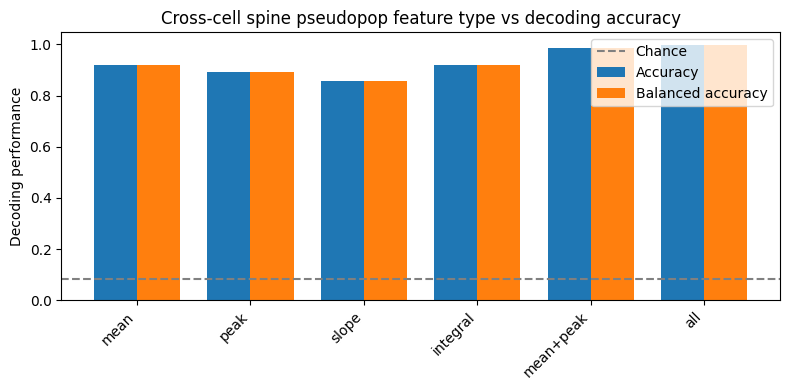

In [151]:
feature_compare = compare_pseudopop_feature_types(
    stim_aligned=stim_aligned,
    iti_aligned=iti_aligned,
    stim_win=slice(0, 120),
    iti_win=slice(0, 50),
    min_repeats_per_spine=3,
    n_draws=100,
    n_splits=25,
    seed_start=0,
)

In [117]:
import numpy as np

def compute_osi_from_aligned(
    stim_aligned,
    iti_aligned,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
    min_repeats_per_spine=1,
):

    # baseline-corrected mean response per row x stim
    stim_resp = stim_aligned[trace_var].isel(time=stim_win).mean("time", skipna=True)
    iti_base = iti_aligned[trace_var].isel(time=iti_win).mean("time", skipna=True)
    resp = stim_resp - iti_base

    resp_values = resp.values                       # (row, stim_index)
    angles_by_si = stim_aligned[stim_angle_coord].values
    unique_angles = np.sort(np.unique(angles_by_si))

    spine_ids = stim_aligned[spine_id_coord].values
    valid_rows = np.where(~np.isnan(spine_ids))[0]

    # row lookup by spine
    sp_to_rows = {}
    for r in valid_rows:
        sid = spine_ids[r]
        sp_to_rows.setdefault(sid, []).append(r)

    keep_spines = np.array([
        sid for sid in sorted(sp_to_rows.keys())
        if len(sp_to_rows[sid]) >= min_repeats_per_spine
    ])

    # average rows within each spine -> (n_spines, n_stim)
    spine_mean_resp = np.stack(
        [resp_values[sp_to_rows[sid], :].mean(axis=0) for sid in keep_spines],
        axis=0
    )

    # average across repeated stimulus presentations of each angle
    tuning = np.stack(
        [spine_mean_resp[:, angles_by_si == ang].mean(axis=1) for ang in unique_angles],
        axis=1
    )  # (n_spines, n_angles)

    theta = np.deg2rad(unique_angles)

    # clamp negatives for OSI calculation
    R = np.maximum(tuning, 0)

    x = (R * np.cos(2 * theta)).sum(axis=1)
    y = (R * np.sin(2 * theta)).sum(axis=1)
    magnitude = np.sqrt(x**2 + y**2)

    osi = magnitude / (R.sum(axis=1) + 1e-9)
    osi_by_spine = dict(zip(keep_spines, osi))

    return {
        "resp_values": resp_values,
        "angles_by_si": angles_by_si,
        "unique_angles": unique_angles,
        "keep_spines": keep_spines,
        "osi": osi,
        "osi_by_spine": osi_by_spine,
    }

In [152]:
pseudopop_osi_results = compute_osi_from_aligned(
    stim_aligned=stim_aligned,
    iti_aligned=iti_aligned,
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
    min_repeats_per_spine=3,
)

pseudopop_osi_by_spine = pseudopop_osi_results["osi_by_spine"]

In [171]:
def pseudopop_osi_removal(
    feature_values,
    angles_by_si,
    keep_spines,
    sp_to_rows,
    osi_by_spine,
    splits,
    n_draws=100,
    seed_start=0,
    fractions=None,
    plot=True,
):

    unique_angles = np.sort(np.unique(angles_by_si))

    if fractions is None:
        fractions = np.linspace(0, 0.5, 10)

    # OSI values aligned to keep_spines
    osi_vals = np.array([osi_by_spine[sid] for sid in keep_spines])
    order = np.argsort(osi_vals)[::-1]
    ranked_spines = keep_spines[order]

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(fractions)))
    bacc_matrix = np.zeros((n_splits, len(fractions)))

    for j, frac in enumerate(fractions):
        n_remove = int(frac * len(ranked_spines))
        spines_subset = ranked_spines[n_remove:]

        X_draws = build_pseudopop_tensor(
            feature_values=feature_values,
            spines=spines_subset,
            sp_to_rows=sp_to_rows,
            n_draws=n_draws,
            rng_seed=seed_start,
        )

        for i, (train_draws, test_draws) in enumerate(splits):
            res = fit_logreg_on_draw_split(
                X_draws=X_draws,
                angles_by_si=angles_by_si,
                train_draws=train_draws,
                test_draws=test_draws,
                unique_angles=unique_angles,
                shuffle_labels=False,
                random_state=seed_start + i,
            )
            acc_matrix[i, j] = res["acc"]
            bacc_matrix[i, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(fractions * 100, mean_acc, marker="o", label="Accuracy")
        plt.fill_between(fractions * 100, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(fractions * 100, mean_bacc, marker="o", label="Balanced accuracy")
        plt.fill_between(fractions * 100, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("% highest-OSI spines removed")
        plt.ylabel("Decoding performance")
        plt.title("Cross-cell spine pseudopop decoding vs removing most selective spines")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "fractions": np.array(fractions),
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

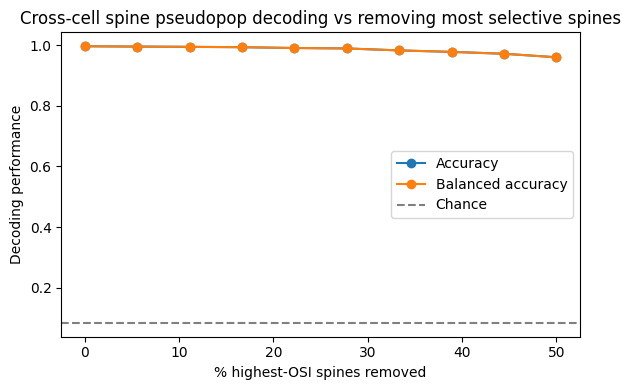

In [172]:
pseudopop_osi_removal_results = pseudopop_osi_removal(
    feature_values=pseudopop_main_results["feature_values"],
    angles_by_si=pseudopop_main_results["angles_by_si"],
    keep_spines=pseudopop_main_results["keep_spines"],
    sp_to_rows=pseudopop_main_results["sp_to_rows"],
    osi_by_spine=pseudopop_osi_by_spine,
    splits=pseudopop_main_results["splits"],
    n_draws=100,
    seed_start=0,
    plot=True,
)

In [173]:
def pseudopop_sliding_window(
    stim_aligned,
    iti_aligned,
    splits,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    iti_win=slice(0, 51),
    window_size=10,
    step_size=1,
    feature_types=("mean",),
    min_repeats_per_spine=3,
    n_draws=100,
    seed_start=0,
    plot=True,
):


    angles_by_si = stim_aligned[stim_angle_coord].values
    unique_angles = np.sort(np.unique(angles_by_si))

    spine_ids = stim_aligned[spine_id_coord].values
    valid_rows = np.where(~np.isnan(spine_ids))[0]

    sp_to_rows = {}
    for r in valid_rows:
        sid = spine_ids[r]
        sp_to_rows.setdefault(sid, []).append(r)

    all_spines = np.array(sorted(sp_to_rows.keys()))
    keep_spines = np.array([
        sid for sid in all_spines if len(sp_to_rows[sid]) >= min_repeats_per_spine
    ])

    n_time = stim_aligned.sizes["time"]
    starts = np.arange(0, n_time - window_size + 1, step_size)
    centers = starts + window_size / 2

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(starts)))
    bacc_matrix = np.zeros((n_splits, len(starts)))

    for j, start in enumerate(starts):
        end = start + window_size

        feature_values, angles_by_si, _, _, _, _ = make_feature_matrix_from_aligned(
            stim_aligned=stim_aligned,
            iti_aligned=iti_aligned,
            trace_var=trace_var,
            spine_id_coord=spine_id_coord,
            stim_angle_coord=stim_angle_coord,
            stim_win=slice(start, end),
            iti_win=iti_win,
            feature_types=feature_types,
        )

        X_draws = build_pseudopop_tensor(
            feature_values=feature_values,
            spines=keep_spines,
            sp_to_rows=sp_to_rows,
            n_draws=n_draws,
            rng_seed=seed_start,
        )

        for i, (train_draws, test_draws) in enumerate(splits):
            res = fit_logreg_on_draw_split(
                X_draws=X_draws,
                angles_by_si=angles_by_si,
                train_draws=train_draws,
                test_draws=test_draws,
                unique_angles=unique_angles,
                shuffle_labels=False,
                random_state=seed_start + i,
            )
            acc_matrix[i, j] = res["acc"]
            bacc_matrix[i, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(7, 4))
        plt.plot(centers, mean_acc, label="Accuracy")
        plt.fill_between(centers, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(centers, mean_bacc, label="Balanced accuracy")
        plt.fill_between(centers, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("Window center (frames)")
        plt.ylabel("Decoding performance")
        plt.title(f"Cross-cell spine pseudopop sliding-window pseudopop decoding")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "window_centers": centers,
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

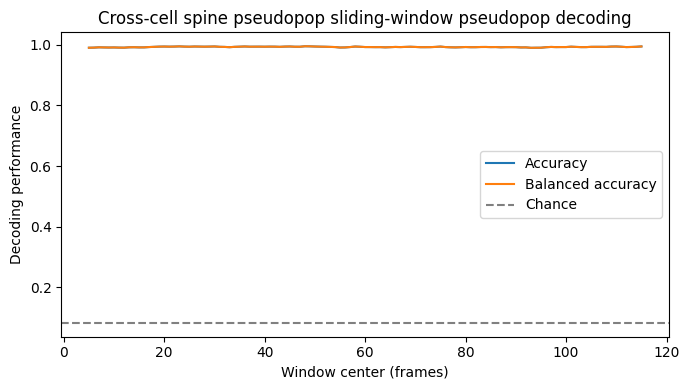

In [174]:
pseudopop_sliding_results = pseudopop_sliding_window(
    stim_aligned=stim_aligned,
    iti_aligned=iti_aligned,
    splits=pseudopop_main_results["splits"],
    iti_win=slice(0, 51),
    window_size=10,
    step_size=1,
    feature_types=("mean", "peak", "slope", "integral"),
    min_repeats_per_spine=3,
    n_draws=100,
    seed_start=0,
    plot=True,
)

## Pseudopopulation with only mean

In [157]:
def make_resp_matrix(
    stim_aligned,
    iti_aligned,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
):
    
    stim_resp = stim_aligned[trace_var].isel(time=stim_win).mean("time", skipna=True)
    iti_base = iti_aligned[trace_var].isel(time=iti_win).mean("time", skipna=True)
    resp = stim_resp - iti_base

    resp_values = resp.values                      # (row, stim_index)
    angles_by_si = stim_aligned[stim_angle_coord].values
    unique_angles = np.sort(np.unique(angles_by_si))

    spine_ids = stim_aligned[spine_id_coord].values
    valid_rows = np.where(~np.isnan(spine_ids))[0]

    sp_to_rows = {}
    for r in valid_rows:
        sid = spine_ids[r]
        sp_to_rows.setdefault(sid, []).append(r)

    keep_spines = np.array(sorted(sp_to_rows.keys()))
    return resp_values, angles_by_si, keep_spines, sp_to_rows, unique_angles


def make_pseudopop_draw(resp_values, spines, sp_to_rows, rng):
    chosen_rows = np.array([rng.choice(sp_to_rows[sid]) for sid in spines])
    R = resp_values[chosen_rows, :]   # (n_spines, n_stim)
    X_draw = R.T                      # (n_stim, n_spines)
    return X_draw



def build_pseudopop_tensor(resp_values, spines, sp_to_rows, n_draws=100, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    n_stim = resp_values.shape[1]
    X_draws = np.zeros((n_draws, n_stim, len(spines)), dtype=np.float64)

    for d in range(n_draws):
        X_draws[d] = make_pseudopop_draw(resp_values, spines, sp_to_rows, rng)

    return X_draws


def make_repeated_draw_splits(n_draws, n_splits=25, test_size=0.2, seed_start=0):
    draw_ids = np.arange(n_draws)
    splits = []

    for i in range(n_splits):
        train_draws, test_draws = train_test_split(
            draw_ids,
            test_size=test_size,
            random_state=seed_start + i,
        )
        splits.append((train_draws, test_draws))

    return splits


def fit_logreg_on_draw_split(
    X_draws,     # X_draws : (n_draws, n_stim, n_spines)
    angles_by_si,
    train_draws,
    test_draws,
    unique_angles=None,
    shuffle_labels=False,
    random_state=0,
    max_iter=5000,
    class_weight="balanced",
):
    
    if unique_angles is None:
        unique_angles = np.sort(np.unique(angles_by_si))

    X_train = X_draws[train_draws].reshape(-1, X_draws.shape[-1])
    X_test = X_draws[test_draws].reshape(-1, X_draws.shape[-1])

    y_train = np.tile(angles_by_si, len(train_draws))
    y_test = np.tile(angles_by_si, len(test_draws))

    if shuffle_labels:
        rng = np.random.default_rng(random_state)
        y_train = rng.permutation(y_train)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=max_iter, class_weight=class_weight)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = (y_pred == y_test).mean()
    bacc = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=unique_angles)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    per_angle_acc = np.diag(cm_norm)

    return {
        "acc": acc,
        "bacc": bacc,
        "cm": cm,
        "cm_norm": cm_norm,
        "per_angle_acc": per_angle_acc,
        "y_test": y_test,
        "y_pred": y_pred,
    }


def pseudopop_mean_window_decode(
    stim_aligned,
    iti_aligned,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    stim_win=slice(0, 120),
    iti_win=slice(0, 50),
    min_repeats_per_spine=3,
    n_draws=100,
    n_splits=25,
    seed_start=0,
    plot=True,
    run_shuffle_control=True,
):
    resp_values, angles_by_si, all_spines, sp_to_rows, unique_angles = make_resp_matrix(
        stim_aligned=stim_aligned,
        iti_aligned=iti_aligned,
        trace_var=trace_var,
        spine_id_coord=spine_id_coord,
        stim_angle_coord=stim_angle_coord,
        stim_win=stim_win,
        iti_win=iti_win,
    )

    keep_spines = np.array([sid for sid in all_spines if len(sp_to_rows[sid]) >= min_repeats_per_spine])

    X_draws = build_pseudopop_tensor(
        resp_values=resp_values,
        spines=keep_spines,
        sp_to_rows=sp_to_rows,
        n_draws=n_draws,
        rng_seed=seed_start,
    )

    splits = make_repeated_draw_splits(
        n_draws=n_draws,
        n_splits=n_splits,
        seed_start=seed_start,
    )

    results = []
    shuf_results = []

    for i, (train_draws, test_draws) in enumerate(splits):
        res = fit_logreg_on_draw_split(
            X_draws=X_draws,
            angles_by_si=angles_by_si,
            train_draws=train_draws,
            test_draws=test_draws,
            unique_angles=unique_angles,
            shuffle_labels=False,
            random_state=seed_start + i,
        )
        results.append(res)

        if run_shuffle_control:
            sres = fit_logreg_on_draw_split(
                X_draws=X_draws,
                angles_by_si=angles_by_si,
                train_draws=train_draws,
                test_draws=test_draws,
                unique_angles=unique_angles,
                shuffle_labels=True,
                random_state=seed_start + i,
            )
            shuf_results.append(sres)

    accs = np.array([r["acc"] for r in results])
    baccs = np.array([r["bacc"] for r in results])
    cms = np.array([r["cm_norm"] for r in results])
    per_angle = np.array([r["per_angle_acc"] for r in results])

    mean_acc = accs.mean()
    sem_acc = accs.std(ddof=1) / np.sqrt(n_splits)

    mean_bacc = baccs.mean()
    sem_bacc = baccs.std(ddof=1) / np.sqrt(n_splits)

    mean_cm = cms.mean(axis=0)
    mean_per_angle = per_angle.mean(axis=0)
    sem_per_angle = per_angle.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if run_shuffle_control:
        shuf_accs = np.array([r["acc"] for r in shuf_results])
        mean_shuf_acc = shuf_accs.mean()
        sem_shuf_acc = shuf_accs.std(ddof=1) / np.sqrt(n_splits)
    else:
        shuf_accs = None
        mean_shuf_acc = None
        sem_shuf_acc = None

    if plot:
        plt.figure(figsize=(7, 7))
        plt.imshow(mean_cm, cmap="viridis", aspect="auto")
        plt.colorbar(label="Mean prediction probability")
        plt.xticks(np.arange(len(unique_angles)), unique_angles, rotation=90)
        plt.yticks(np.arange(len(unique_angles)), unique_angles)
        plt.xlabel("Predicted angle")
        plt.ylabel("True angle")
        plt.title(
            f"Cross-cell spines pseudopop mean-window decoder (feature = mean only)\n"
            f"acc={mean_acc:.3f} ± {sem_acc:.3f}, "
            f"bal acc={mean_bacc:.3f} ± {sem_bacc:.3f}"
        )

        for i, val in enumerate(mean_per_angle):
            plt.text(
                i, i, f"{val:.2f}",
                ha="center", va="center",
                color="white" if val < 0.5 else "black",
                fontsize=9, fontweight="bold"
            )
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.bar(unique_angles, mean_per_angle, yerr=sem_per_angle, capsize=4, width=20)
        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xticks(unique_angles, rotation=90)
        plt.xlabel("Angle (degrees)")
        plt.ylabel("Accuracy")
        plt.title("Cross-cell spines pseudopop per-angle decoding accuracy (feature = mean only)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        if run_shuffle_control:
            plt.figure(figsize=(5, 4))
            plt.bar(
                ["Real", "Shuffled"],
                [mean_acc, mean_shuf_acc],
                yerr=[sem_acc, sem_shuf_acc],
                capsize=4,
            )
            plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
            plt.ylabel("Accuracy")
            plt.title("Cross-cell spines pseudopop decoder vs shuffled-label control (feature = mean only)")
            plt.legend()
            plt.tight_layout()
            plt.show()

    return {
        "resp_values": resp_values,
        "angles_by_si": angles_by_si,
        "keep_spines": keep_spines,
        "sp_to_rows": sp_to_rows,
        "unique_angles": unique_angles,
        "X_draws": X_draws,
        "splits": splits,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
        "mean_cm": mean_cm,
        "mean_per_angle": mean_per_angle,
        "sem_per_angle": sem_per_angle,
        "mean_shuf_acc": mean_shuf_acc,
        "sem_shuf_acc": sem_shuf_acc,
    }



def pseudopop_osi_removal(
    resp_values,
    angles_by_si,
    keep_spines,
    sp_to_rows,
    osi_by_spine,
    splits,
    n_draws=100,
    seed_start=0,
    fractions=None,
    plot=True,
):
    unique_angles = np.sort(np.unique(angles_by_si))

    if fractions is None:
        fractions = np.linspace(0, 0.5, 10)

    # keep_spines should already be filtered by min repeats
    osi_vals = np.array([osi_by_spine[sid] for sid in keep_spines])
    order = np.argsort(osi_vals)[::-1]  # highest OSI first
    ranked_spines = keep_spines[order]

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(fractions)))
    bacc_matrix = np.zeros((n_splits, len(fractions)))

    for j, frac in enumerate(fractions):
        n_remove = int(frac * len(ranked_spines))
        spines_subset = ranked_spines[n_remove:]

        X_draws = build_pseudopop_tensor(
            resp_values=resp_values,
            spines=spines_subset,
            sp_to_rows=sp_to_rows,
            n_draws=n_draws,
            rng_seed=seed_start,
        )

        for i, (train_draws, test_draws) in enumerate(splits):
            res = fit_logreg_on_draw_split(
                X_draws=X_draws,
                angles_by_si=angles_by_si,
                train_draws=train_draws,
                test_draws=test_draws,
                unique_angles=unique_angles,
                shuffle_labels=False,
                random_state=seed_start + i,
            )
            acc_matrix[i, j] = res["acc"]
            bacc_matrix[i, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(fractions * 100, mean_acc, marker="o", label="Accuracy")
        plt.fill_between(fractions * 100, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(fractions * 100, mean_bacc, marker="o", label="Balanced accuracy")
        plt.fill_between(fractions * 100, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("% highest-OSI spines removed")
        plt.ylabel("Decoding performance")
        plt.title("Cross-cell spines pseudopop decoding vs removing most selective spines (feature = mean only)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "fractions": np.array(fractions),
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }



def pseudopop_sliding_window(
    stim_aligned,
    iti_aligned,
    splits,
    trace_var="trace",
    spine_id_coord="spine_id",
    stim_angle_coord="stim",
    iti_win=slice(0, 51),
    window_size=10,
    step_size=1,
    min_repeats_per_spine=3,
    n_draws=100,
    seed_start=0,
    plot=True,
):
    # baseline once
    iti_base = iti_aligned[trace_var].isel(time=iti_win).mean("time", skipna=True)
    angles_by_si = stim_aligned[stim_angle_coord].values
    unique_angles = np.sort(np.unique(angles_by_si))

    spine_ids = stim_aligned[spine_id_coord].values
    valid_rows = np.where(~np.isnan(spine_ids))[0]

    sp_to_rows = {}
    for r in valid_rows:
        sid = spine_ids[r]
        sp_to_rows.setdefault(sid, []).append(r)

    all_spines = np.array(sorted(sp_to_rows.keys()))
    keep_spines = np.array([sid for sid in all_spines if len(sp_to_rows[sid]) >= min_repeats_per_spine])

    n_time = stim_aligned.sizes["time"]
    starts = np.arange(0, n_time - window_size + 1, step_size)
    centers = starts + window_size / 2

    n_splits = len(splits)
    acc_matrix = np.zeros((n_splits, len(starts)))
    bacc_matrix = np.zeros((n_splits, len(starts)))

    for j, start in enumerate(starts):
        end = start + window_size

        stim_resp = stim_aligned[trace_var].isel(time=slice(start, end)).mean("time", skipna=True)
        resp = stim_resp - iti_base
        resp_values = resp.values

        X_draws = build_pseudopop_tensor(
            resp_values=resp_values,
            spines=keep_spines,
            sp_to_rows=sp_to_rows,
            n_draws=n_draws,
            rng_seed=seed_start,
        )

        for i, (train_draws, test_draws) in enumerate(splits):
            res = fit_logreg_on_draw_split(
                X_draws=X_draws,
                angles_by_si=angles_by_si,
                train_draws=train_draws,
                test_draws=test_draws,
                unique_angles=unique_angles,
                shuffle_labels=False,
                random_state=seed_start + i,
            )
            acc_matrix[i, j] = res["acc"]
            bacc_matrix[i, j] = res["bacc"]

    mean_acc = acc_matrix.mean(axis=0)
    sem_acc = acc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    mean_bacc = bacc_matrix.mean(axis=0)
    sem_bacc = bacc_matrix.std(axis=0, ddof=1) / np.sqrt(n_splits)

    if plot:
        plt.figure(figsize=(7, 4))
        plt.plot(centers, mean_acc, label="Accuracy")
        plt.fill_between(centers, mean_acc - sem_acc, mean_acc + sem_acc, alpha=0.2)

        plt.plot(centers, mean_bacc, label="Balanced accuracy")
        plt.fill_between(centers, mean_bacc - sem_bacc, mean_bacc + sem_bacc, alpha=0.2)

        plt.axhline(1 / len(unique_angles), linestyle="--", color="gray", label="Chance")
        plt.xlabel("Window center (frames)")
        plt.ylabel("Decoding performance")
        plt.title("Cross-cell spines sliding-window pseudopop decoding (feature = mean only)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "window_centers": centers,
        "acc_matrix": acc_matrix,
        "bacc_matrix": bacc_matrix,
        "mean_acc": mean_acc,
        "sem_acc": sem_acc,
        "mean_bacc": mean_bacc,
        "sem_bacc": sem_bacc,
    }

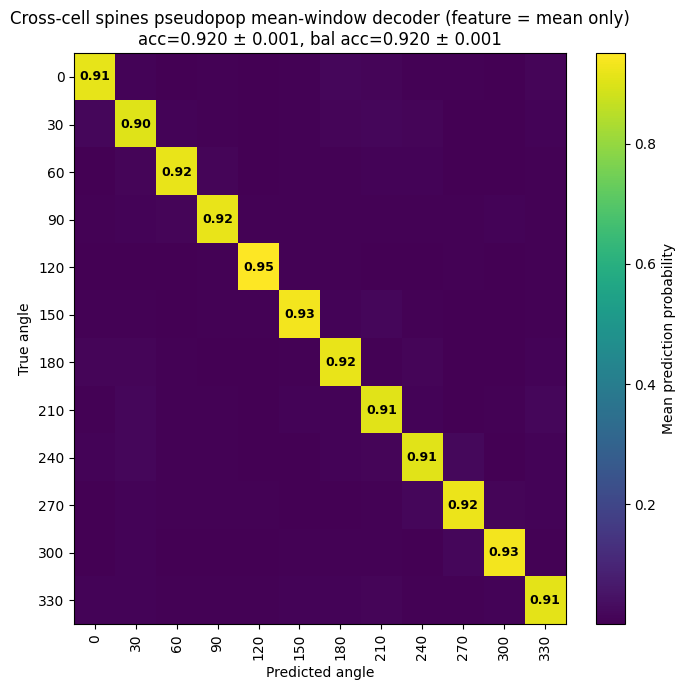

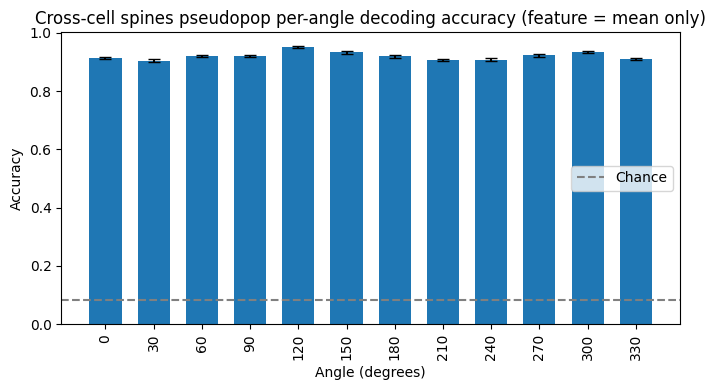

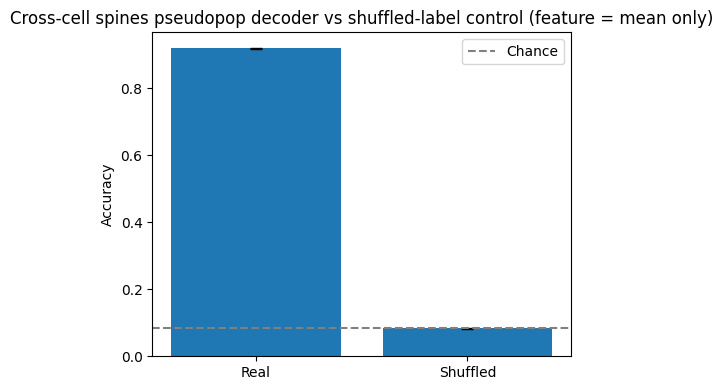

In [158]:
pseudopop_mean_results = pseudopop_mean_window_decode(
    stim_aligned=stim_aligned,
    iti_aligned=iti_aligned,
    stim_win=slice(0, 120),
    iti_win=slice(0, 51),
    min_repeats_per_spine=3,
    n_draws=100,
    n_splits=25,
    seed_start=0,
    plot=True,
    run_shuffle_control=True,
)

In [159]:
resp, all_angles, unique_angles, osi = compute_OSI(stim_data, iti_data, stim_angles)

osi_by_spine = dict(zip(spine_ids, osi))

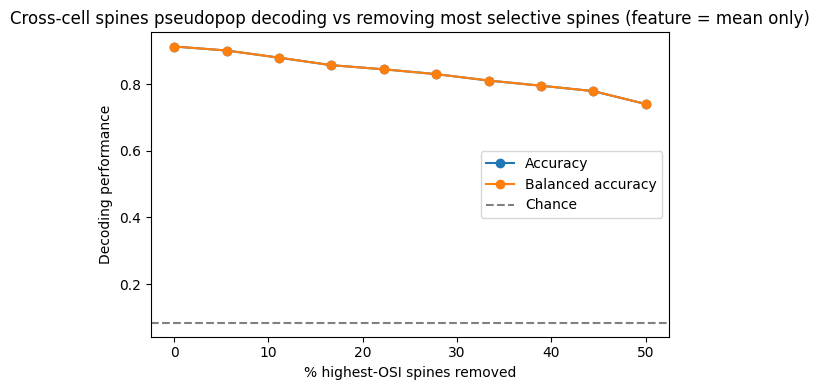

In [160]:
osi_res = pseudopop_osi_removal(
    resp_values=pseudopop_mean_results["resp_values"],
    angles_by_si=pseudopop_mean_results["angles_by_si"],
    keep_spines=pseudopop_mean_results["keep_spines"],
    sp_to_rows=pseudopop_mean_results["sp_to_rows"],
    osi_by_spine=osi_by_spine,
    splits=pseudopop_mean_results["splits"],
    n_draws=100,
    seed_start=0,
    plot=True,
)

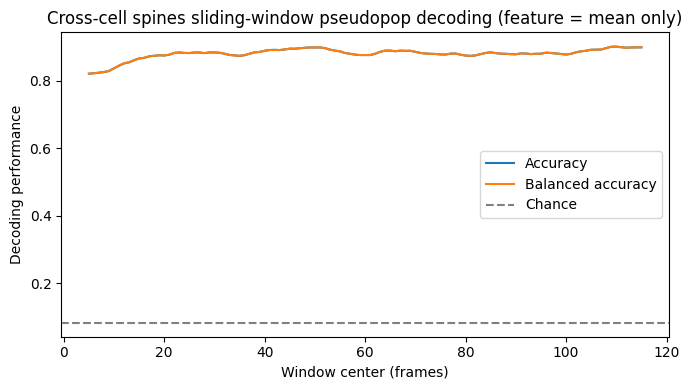

In [161]:
time_res = pseudopop_sliding_window(
    stim_aligned=stim_aligned,
    iti_aligned=iti_aligned,
    splits=pseudopop_mean_results["splits"],
    iti_win=slice(0, 51),
    window_size=10,
    step_size=1,
    min_repeats_per_spine=3,
    n_draws=100,
    seed_start=0,
    plot=True,
)